# Tarefa Machine Learning - Evandro Rhari

In [233]:
import pandas as pd
import numpy as np

import sklearn as sk

import seaborn as sns
import matplotlib.pyplot as plt

In [234]:
paleta_qualitativa = sns.color_palette("Set1")
sns.set_palette(paleta_qualitativa)

paleta_continua = sns.color_palette("mako", as_cmap=True)

sns.set_style("whitegrid")

## Parte 1: Regressão — Student Performance

### 1.1 Análise Exploratória

A princípio, vamos dar uma olhada nos dados que temos!

In [235]:
df_treino = pd.read_csv('./regressao/train.csv')
df_treino

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,score
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,no,4,3,4,1,1,3,6,5.67
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,no,5,3,3,1,1,3,4,5.33
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,no,4,3,2,2,3,3,10,8.33
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,3,2,2,1,1,5,2,14.67
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,no,4,3,2,1,2,5,4,8.67
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,no,no,5,5,4,4,5,4,11,9.00
391,MS,M,17,U,LE3,T,3,1,services,services,...,yes,no,2,4,5,3,4,2,3,15.33
392,MS,M,21,R,GT3,T,1,1,other,other,...,no,no,5,5,3,3,3,3,3,8.33
393,MS,M,18,R,LE3,T,3,2,services,other,...,yes,no,4,4,1,3,4,5,0,11.00


In [236]:
df_treino.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,score
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.679139
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.696912
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.330000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.330000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,10.670000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.330000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.330000


Aqui, podemos observar um pouco da natureza categórica de muitas colunas numéricas através dos valores máximos e minimos.

Podemos ver também que metdade das notas está entre 8.33 e 13.33, um intervado de apenas 5 pontos, que é 1/4 do máximo, deixado a média em 10.67. Além disso, nenhum score é máximo, sendo o maior dos seus valores 19.33.

Para entender melhor as colunas, é necessário ler o arquivo `./regressao/students/txt`

In [237]:
df_treino.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 31 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   school      395 non-null    str    
 1   sex         395 non-null    str    
 2   age         395 non-null    int64  
 3   address     395 non-null    str    
 4   famsize     395 non-null    str    
 5   Pstatus     395 non-null    str    
 6   Medu        395 non-null    int64  
 7   Fedu        395 non-null    int64  
 8   Mjob        395 non-null    str    
 9   Fjob        395 non-null    str    
 10  reason      395 non-null    str    
 11  guardian    395 non-null    str    
 12  traveltime  395 non-null    int64  
 13  studytime   395 non-null    int64  
 14  failures    395 non-null    int64  
 15  schoolsup   395 non-null    str    
 16  famsup      395 non-null    str    
 17  paid        395 non-null    str    
 18  activities  395 non-null    str    
 19  nursery     395 non-null    str    
 20 

Vamos dar uma olhada na correlação entre os dados numéricos

<Axes: >

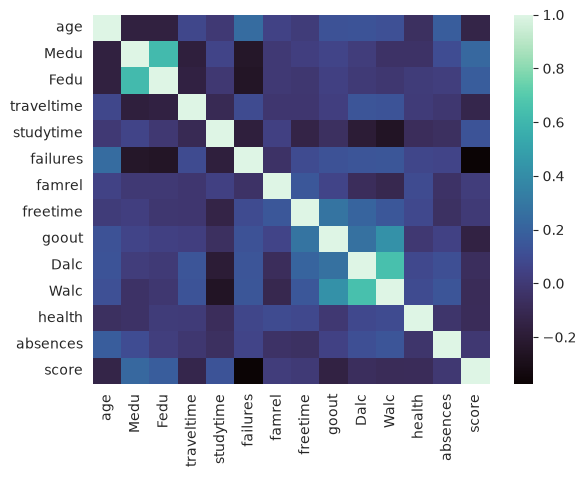

In [238]:
dfnumerical = df_treino.select_dtypes(include=np.number)
sns.heatmap(dfnumerical.corr(), cmap=paleta_continua)

Estamos especialmente interessados na última coluna do gráfico Não vemos nenhuma correlação positiva muito interessante, porém vemos que a quantidade de falhas prévias está inversamente relacionado com a nota atual.

Importante notar que as colunas numéricas não são muito fortemente relacionadas a nota final, enfatizando a importância das colunas categóricas.

## 1.2 Limpeza e pré-processamento

A princípio vemos que não temos nenhum dados nulo, mas será que todos os tipos são adequados? Em relação ao tipo de dado de cada campo, estão, porém alguma curadoria pode ser interessante.

Podemos observar, desde a análise exploratória, que temos muitos dados categóricos. Porém, modelos de regressão recebem inputs numéricos. Alguns deles já são dados numéricos disfarçados, porém alguns ainda são texto e, portanto, devem ser tratados. Se deixarmos do jeito que está, teremos que perder esses dados, possivelmente deteriorando a acurácia do nosso modelo.

Podemos começar com os dados `str` que, na verdade, são booleanos salvos com valores 'yes' e 'no'. Podemos converter isso para bool.

In [ ]:
# garantindo que não tem nenhuma inconsistência dentro dos dados.
bool_cols = ['famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'schoolsup']
for bool_col in bool_cols:
    print(df_treino[bool_col].unique())

<ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str
<ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str
<ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str
<ArrowStringArray>
['yes', 'no']
Length: 2, dtype: str
<ArrowStringArray>
['yes', 'no']
Length: 2, dtype: str
<ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str
<ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str
<ArrowStringArray>
['yes', 'no']
Length: 2, dtype: str


In [ ]:
# convertendo para bool
df_treino[bool_cols] = df_treino[bool_cols] == 'yes'
df_treino[bool_cols]

,famsup,paid,activities,nursery,higher,internet,romantic,schoolsup
0,False,False,False,True,True,False,False,True
1,True,False,False,False,True,True,False,False
2,False,True,False,True,True,True,False,True
3,True,True,True,True,True,True,True,False
4,True,True,False,True,True,False,False,False
...,...,...,...,...,...,...,...,...
390,True,True,False,True,True,False,False,False
391,False,False,False,False,True,True,False,False
392,False,False,False,False,True,False,False,False
393,False,False,False,False,True,True,False,False


Vamos fazer o mesmo com o dataset de teste.

In [241]:
df_teste = pd.read_csv('./regressao/test.csv')
df_teste

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences
0,GP,M,16,U,LE3,T,2,2,other,services,...,yes,yes,yes,1,5,3,1,1,5,0
1,GP,M,15,U,GT3,T,2,1,other,other,...,yes,no,no,5,4,3,2,1,3,5
2,GP,M,16,U,GT3,A,1,4,services,teacher,...,no,yes,yes,4,3,2,1,2,4,6
3,GP,M,16,U,LE3,T,3,4,services,other,...,yes,yes,no,4,1,4,1,3,4,2
4,GP,F,18,R,GT3,T,3,3,teacher,other,...,yes,no,yes,4,5,3,1,1,5,0
5,GP,M,18,U,LE3,T,4,1,other,at_home,...,no,yes,no,5,3,4,1,1,5,11
6,GP,M,19,U,LE3,T,4,2,services,other,...,yes,yes,no,4,5,2,1,1,5,7
7,GP,F,16,R,GT3,T,1,1,other,services,...,yes,yes,no,3,5,4,5,1,2,7
8,GP,M,20,U,GT3,T,4,3,services,other,...,yes,yes,no,4,3,2,1,2,5,11
9,MS,F,18,U,GT3,T,1,4,teacher,other,...,yes,yes,no,5,3,4,1,1,5,1


In [242]:
df_teste[bool_cols] = df_teste[bool_cols] == 'yes'

Pronto! Agora podemos lidar com os outros dados categóricos, escritos em texto. A estratégia que vamos usar é o [One Hot Encoding](https://www.geeksforgeeks.org/machine-learning/ml-one-hot-encoding/), uma vez que temos poucas categorias (menos 1000) ao todo e que, a princípio, não parece ter nenhuma relação semântica entre as categorias de uma mesma coluna. Outra possibilidade seria o embedding, mas, para esse caso simples e pequeno, ele seria menos apropriado. 

In [243]:
categorical_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian']
df_treino_encoded = pd.get_dummies(df_treino, columns=categorical_cols, dtype=bool)
df_teste_encoded = pd.get_dummies(df_teste, columns=categorical_cols, dtype=bool)

In [244]:
df_treino_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 49 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                395 non-null    int64  
 1   Medu               395 non-null    int64  
 2   Fedu               395 non-null    int64  
 3   traveltime         395 non-null    int64  
 4   studytime          395 non-null    int64  
 5   failures           395 non-null    int64  
 6   schoolsup          395 non-null    bool   
 7   famsup             395 non-null    bool   
 8   paid               395 non-null    bool   
 9   activities         395 non-null    bool   
 10  nursery            395 non-null    bool   
 11  higher             395 non-null    bool   
 12  internet           395 non-null    bool   
 13  romantic           395 non-null    bool   
 14  famrel             395 non-null    int64  
 15  freetime           395 non-null    int64  
 16  goout              395 non-null    in

Pode ocorrer que uma categoria que aparece no treino não aparece no teste, então temos que colocar inserir manualmente essa coluna no dataframe de teste.

In [245]:
for col in df_treino_encoded.columns:
    if col != 'score' and not col in df_teste_encoded.columns:
        df_teste_encoded[col] = pd.Series(np.zeros(df_treino_encoded[col].size))

df_treino_encoded = df_treino_encoded.reindex(sorted(df_treino_encoded.columns), axis=1)
df_teste_encoded  = df_teste_encoded.reindex(sorted(df_teste_encoded.columns), axis=1)

Como o dataset de teste não tem o score, não iremos saber a acurácia do nosso modelo se só usarmos ele. Dessa forma, vamos dividir o dataset de treino em dois: 80% para treino, 20% para verificação.

In [ ]:
df_treino_set = df_treino_encoded.sample(frac=0.8, random_state=1273)
df_verificacao_set = df_treino_encoded.drop(df_treino_set.index)

df_treino_set.shape, df_verificacao_set.shape

# um método equivalente seria: 
# df_treino_set, df_verificacao_set = sk.model_selection.train_test_split(df_treino_encoded, random_state=1273, test_size=0.2)

((316, 49), (79, 49))

Por fim, vamos normalizar os valores para garantir que grandes magnetudes não vão enviezar o modelo.

In [307]:
scaler = sk.preprocessing.StandardScaler()
df_treino_set_normalizado = scaler.fit_transform(df_treino_set.drop('score', axis=1))
df_verificacao_set_normalizado = scaler.transform(df_verificacao_set.drop('score', axis=1))
df_teste_set_normalizado = scaler.transform(df_teste_encoded)

Com os dados divididos, podemos podemos começar a treinar os modelos!

### 1.3 Modelo de inferência

#### Regressão Linear
Pra começar, vamos usar um modelo simples de regressão linear.

In [308]:
linreg = sk.linear_model.LinearRegression()
linreg.fit(df_treino_set_normalizado, y=df_treino_set['score'])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](48,)","[ 0.01, 0.07, 0.05,..., 0.25, 0.44,-0.06]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,10.71
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,48
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(39)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](48,)","[35.81,31.29,28.29,..., 0. , 0. , 0. ]"


In [309]:
linprediction = linreg.predict(df_verificacao_set_normalizado)
linprediction

array([ 9.5535009 , 13.47855265, 12.95453473, 12.42334005,  8.98648178,
       10.97873528, 14.47544157,  8.84330037,  8.89609891, 11.294728  ,
       10.75318457, 10.94218666, 11.50879026, 13.29638914, 12.18320146,
       10.81452176, 10.66583059, 12.9332266 , 10.08747533, 11.65059408,
       14.5300646 ,  7.89283704, 14.4040813 ,  9.52974797, 10.1727244 ,
        3.50093092,  7.24767455, 11.96556622,  6.80177003, 12.48165873,
       10.01434412, 11.28059629, 10.73701692,  5.05705483,  9.60602339,
       10.41638716, 11.82461024, 12.41676484, 11.31987692, 14.06101691,
        9.51308742, 11.34242086, 11.31600766, 10.5733937 ,  9.77796029,
       12.3084576 ,  9.39764211,  9.79029186, 13.95407799,  5.36132061,
        9.33476396, 11.61930683, 12.16933269, 10.52206195, 10.83738596,
       12.22939014,  9.32216072, 10.73980655,  8.01288762, 11.27651116,
       10.6759677 , 11.05196536, 14.05422436, 13.31617817, 11.70691268,
        9.07236525,  9.84946289, 12.20453911, 10.77134347, 11.79

#### Random Forest
Agora vamos tentar algo um pouco mais sofisticado: uma Random Forest

In [310]:
rfreg = sk.ensemble.RandomForestRegressor()
rfreg.fit(df_treino_set_normalizado, y=df_treino_set['score'])

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the numb

In [311]:
rfprediction = rfreg.predict(df_verificacao_set_normalizado)
rfprediction

array([10.0928, 13.8761, 13.2565, 11.056 ,  9.8736, 12.0935, 12.8402,
        9.603 , 10.7434, 11.2495, 10.5068, 11.9762, 10.2794, 12.4696,
       12.9628,  9.7367, 10.6666, 11.9732, 10.5571, 11.6641, 15.4527,
        5.7372, 13.4023, 10.2831,  9.7524,  9.7872,  4.4564, 10.5024,
        5.0507, 12.4526,  8.5406, 12.4502, 11.5162,  8.2897,  8.7147,
       10.7461, 10.8325, 11.5727, 12.3832, 11.06  , 10.1764, 11.3296,
       12.2465, 11.7388,  9.4596, 12.083 , 10.9333, 11.3494, 13.6962,
        7.8292,  8.8736, 11.3307, 14.193 , 11.5361, 11.9691, 11.7764,
       10.3502, 11.5869,  9.1967, 12.0658,  9.18  , 12.883 , 12.6001,
       13.7465, 11.133 ,  6.0781, 11.5697, 12.3041, 12.5167, 12.4326,
       10.7235, 12.1195, 11.1928, 11.2401,  8.8792,  9.2634, 13.4267,
       11.0274,  5.564 ])

### 1.4 Metrida de Avaliação

In [312]:
gabarito = df_verificacao_set['score']
length = linprediction.size

In [313]:
def scatter_plot_avaliacao(prediction, ax_infe=None, ax_real=None):
    plot_infe = sns.scatterplot(x=range(length), y=prediction, label='Inferência', ax=ax_infe)
    plot_real = sns.scatterplot(x=range(length), y=gabarito, label='Valor Real', ax=ax_real)

    plt.xlabel("Index do Dado")
    plt.ylabel("score")

    plot_real.grid(True)
    plot_real.set_xticks(range(prediction.size), minor=False)
    plot_real.tick_params("x", rotation=90, rotation_mode="xtick")
    return (plot_infe, plot_real)

In [314]:
def erros_quadrados(prediction):
    return [(p-g)**2 for (p,g) in zip(prediction, gabarito)]

In [315]:
def line_plot_erros_quadrados(prediction, ax=None, color=None):
    erro = erros_quadrados(prediction)
    plot = sns.lineplot(x=range(length), y=erro, ax=ax, color=color)
    plt.xlabel("Index do Dado")
    plt.ylabel("Erro Quadrados\n(p-g)²")
    return plot

In [316]:
def plot_pontos_e_erro(prediction):
    fig, ax1 = plt.subplots()
    fig.set_figwidth(15)
    fig.set_figheight(5)
    ax2 = ax1.twinx()

    scatter_plot_avaliacao(prediction, ax_infe=ax1, ax_real=ax1)
    line_plot_erros_quadrados(prediction, ax=ax2, color=paleta_qualitativa[3])

    ax1.yaxis.grid(False)
    ax2.legend(['Erro Quadrado'])

Vamos fazer uns gráficos!

(<Axes: title={'center': 'Random Forest'}, xlabel='Index do Dado', ylabel='score'>,
 <Axes: title={'center': 'Random Forest'}, xlabel='Index do Dado', ylabel='score'>)

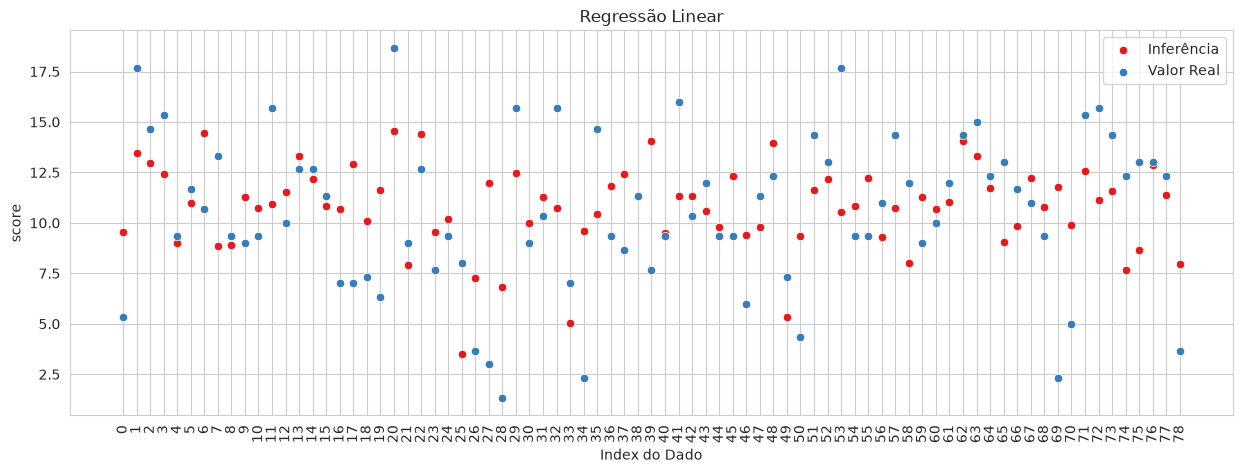

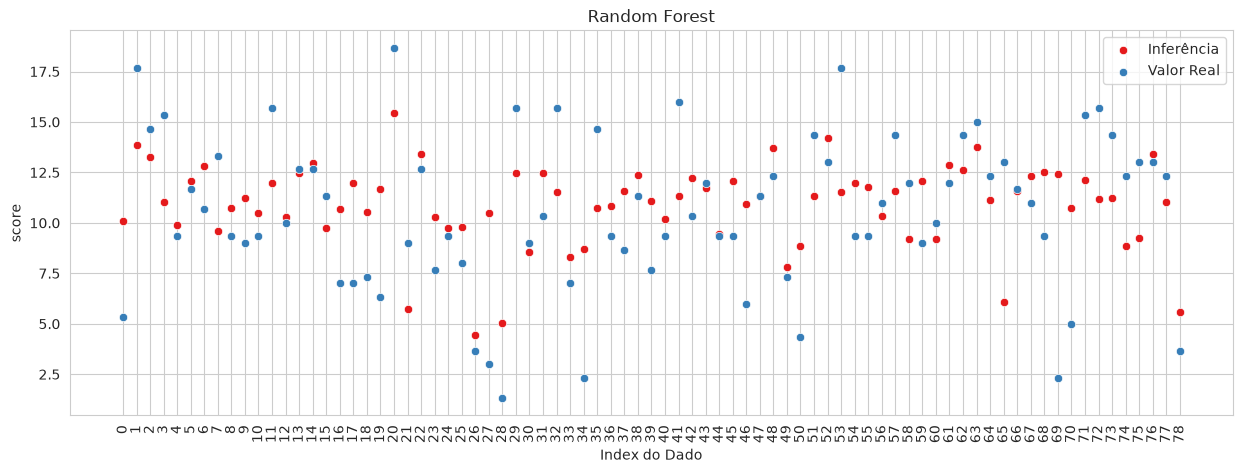

In [317]:
plt.figure(figsize=(15,5))
plt.title("Regressão Linear")
scatter_plot_avaliacao(linprediction)

plt.figure(figsize=(15,5))
plt.title("Random Forest")
scatter_plot_avaliacao(rfprediction)

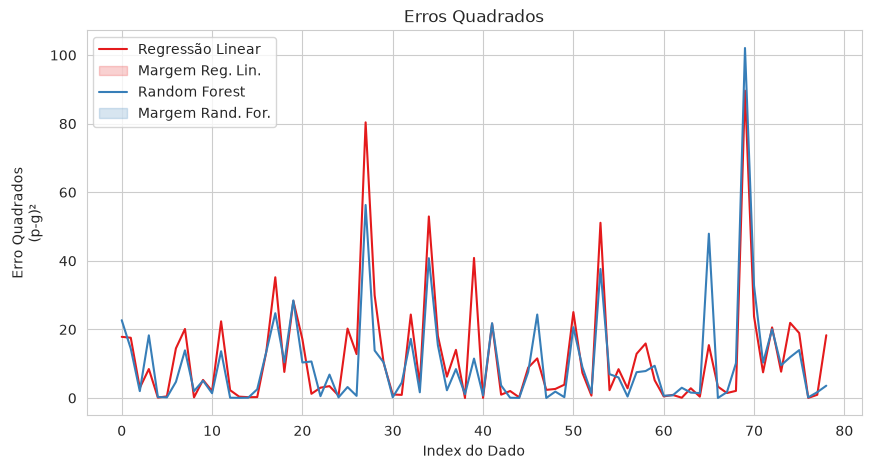

In [318]:
plt.figure(figsize=(10,5))
plt.title("Erros Quadrados")
line_plot_erros_quadrados(linprediction)
line_plot_erros_quadrados(rfprediction)
plt.legend(['Regressão Linear', 'Margem Reg. Lin.', 'Random Forest', 'Margem Rand. For.'])

Text(0.5, 1.0, 'Random Forest')

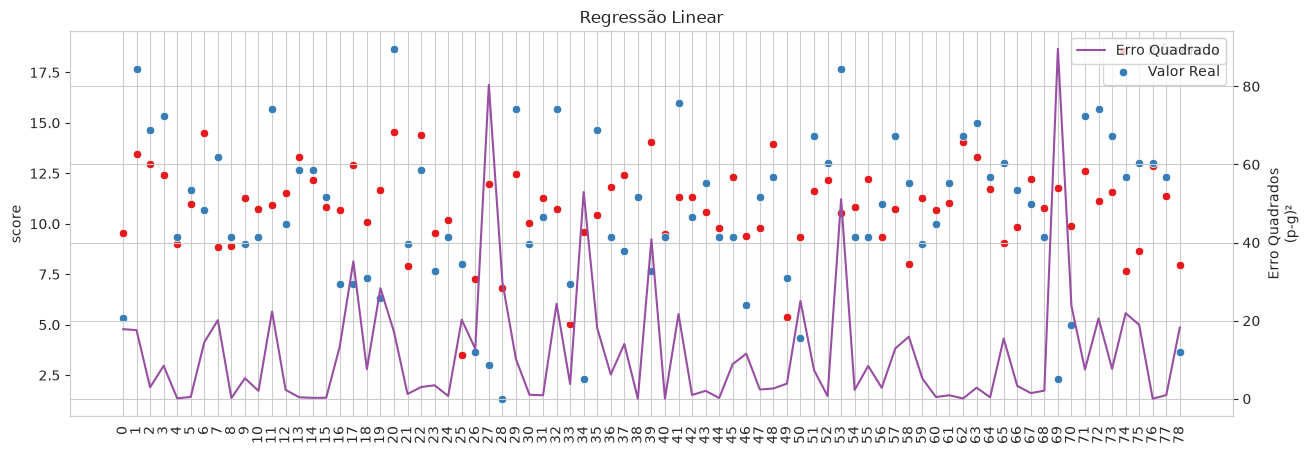

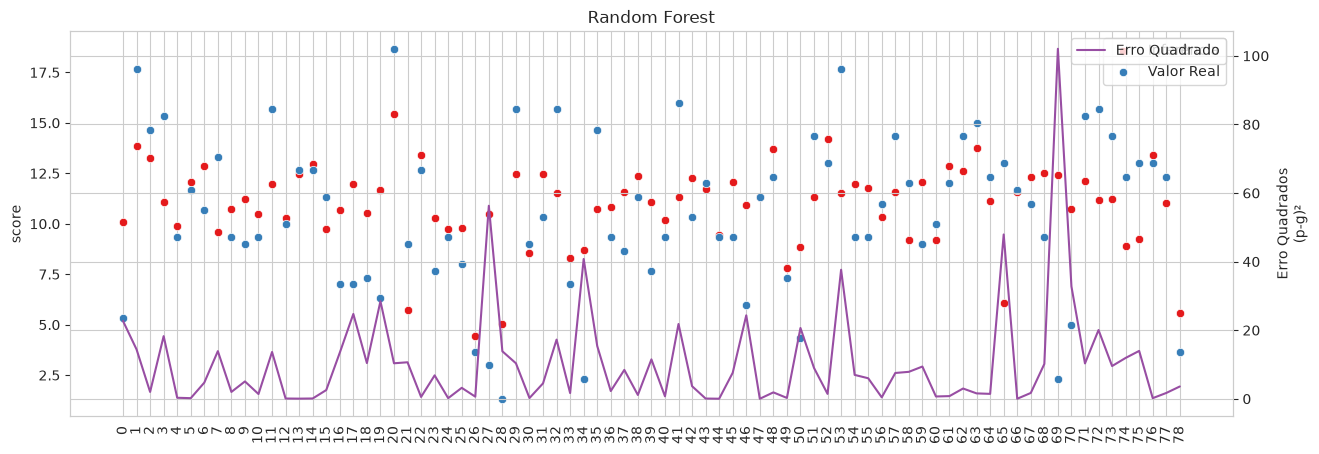

In [319]:
plot_pontos_e_erro(linprediction)
plt.title("Regressão Linear")
plot_pontos_e_erro(rfprediction)
plt.title("Random Forest")

In [320]:
rmse = lambda pred: np.sqrt(np.sum(erros_quadrados(pred))/length)
print(f"Regressão Linear:\t{rmse(linprediction)}")
print(f"Random Forest:\t\t{rmse(rfprediction)}")

Regressão Linear:	3.4911970330970408
Random Forest:		3.250395797612845


Podemos ver que ambos os algorítimos, sem nenhum fine tunning, tem aproximadamente o mesmo desempenho, com rmse próximo de 3.5.

Ambos não costumam a alcançar valores muito extremos de nota, resultado em picos de erros. Até mesmo os picos ocorrem, de forma geral, no mesmo momento.

Por fim, usaremos o algorítmo com menor erro, o Random Forest, para aplicar no dataset de teste.

In [321]:
rfreg.predict(df_teste_encoded)

/home/erhari/Desktop/Pastas/python-stuff/ufrj-analytica-training/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


array([ 9.5666, 11.0596,  9.4562, 11.7897, 10.9572, 10.6332, 10.9432,
       11.6461, 11.9629, 11.3196, 10.9035, 11.7233, 10.853 , 11.5969,
       11.4695, 11.32  , 10.8436, 11.6829,  9.7197,  9.7091])

## Parte 2: Classificação ー Breast Cancer

In [ ]:
df_treino2 = pd.read_csv('./classiicacao/train2.csv') # 'clasiicacao' ー typo da estrutura do projeto
df_treino2

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [ ]:
df_teste2 = pd.read_csv('./classiicacao/test2.csv')
df_teste2

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,13.761,22.32,74.28,460.7,0.09099,0.04700,0.011736,0.018453,0.1420,0.05717,...,14.524,34.22,98.19,504.6,0.09290,0.13222,0.045694,0.055390,0.2679,0.07430
1,17.725,17.26,108.50,327.8,0.10533,0.12086,0.183453,0.108418,0.2053,0.06019,...,15.706,30.84,155.31,563.2,0.14101,0.32176,0.352371,0.224176,0.3722,0.12992
2,10.470,15.85,92.25,689.6,0.10665,0.21764,0.175923,0.027157,0.1782,0.07305,...,12.262,32.29,79.24,1383.0,0.13660,0.32830,0.409569,0.194510,0.5297,0.11131
3,20.049,25.93,119.83,727.6,0.12206,0.11893,0.191121,0.115295,0.2023,0.06509,...,19.540,24.22,158.79,1158.7,0.17343,0.40155,0.693842,0.223328,0.3340,0.12167
4,10.453,20.57,71.12,306.2,0.08969,0.03472,0.044487,0.018594,0.1533,0.05589,...,14.059,33.57,63.38,578.0,0.10315,0.11903,0.001989,0.039697,0.2915,0.07302
5,19.018,21.15,114.81,898.6,0.08999,0.12311,0.166870,0.090104,0.1677,0.05606,...,20.855,23.58,172.17,2222.9,0.10784,0.35809,0.393884,0.180009,0.2842,0.07791
6,13.794,15.78,66.16,209.7,0.07441,0.05774,0.000239,0.000000,0.1582,0.06378,...,12.879,18.53,75.11,703.1,0.08744,0.02939,0.069478,0.009252,0.2449,0.07377
7,12.320,11.30,74.18,336.6,0.09824,0.08264,0.081353,0.074278,0.1685,0.05802,...,12.682,20.18,84.14,434.8,0.11695,0.30761,0.195087,0.074133,0.3278,0.09231
8,9.849,12.14,60.94,224.4,0.09650,0.03371,0.034005,0.019300,0.2061,0.06257,...,11.377,23.44,71.95,253.0,0.08839,0.03852,0.000000,0.027754,0.3534,0.09660
9,11.574,24.06,64.61,387.7,0.08998,0.06732,0.019102,0.021827,0.1865,0.06093,...,13.823,31.60,77.99,334.2,0.07711,0.13089,0.048535,0.066166,0.3045,0.07414


### 2.1 Análise Exploratória

In [324]:
df_treino2.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    str    
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  569 non-null

Podemos ver que todos os dados, menos `diagnosis`, são floats.

Vamos dar uma olhada na correlação desses campos através de vários gráficos de disperssão. A vantagem desse médodo acima de um heatmap é que podemos ver cada linha da tabela individualmente como um ponto e pintá-la de acordo com o seu diagnóstico. Nesse caso, vermelho significa 'Maligno' e azul 'Benigno'

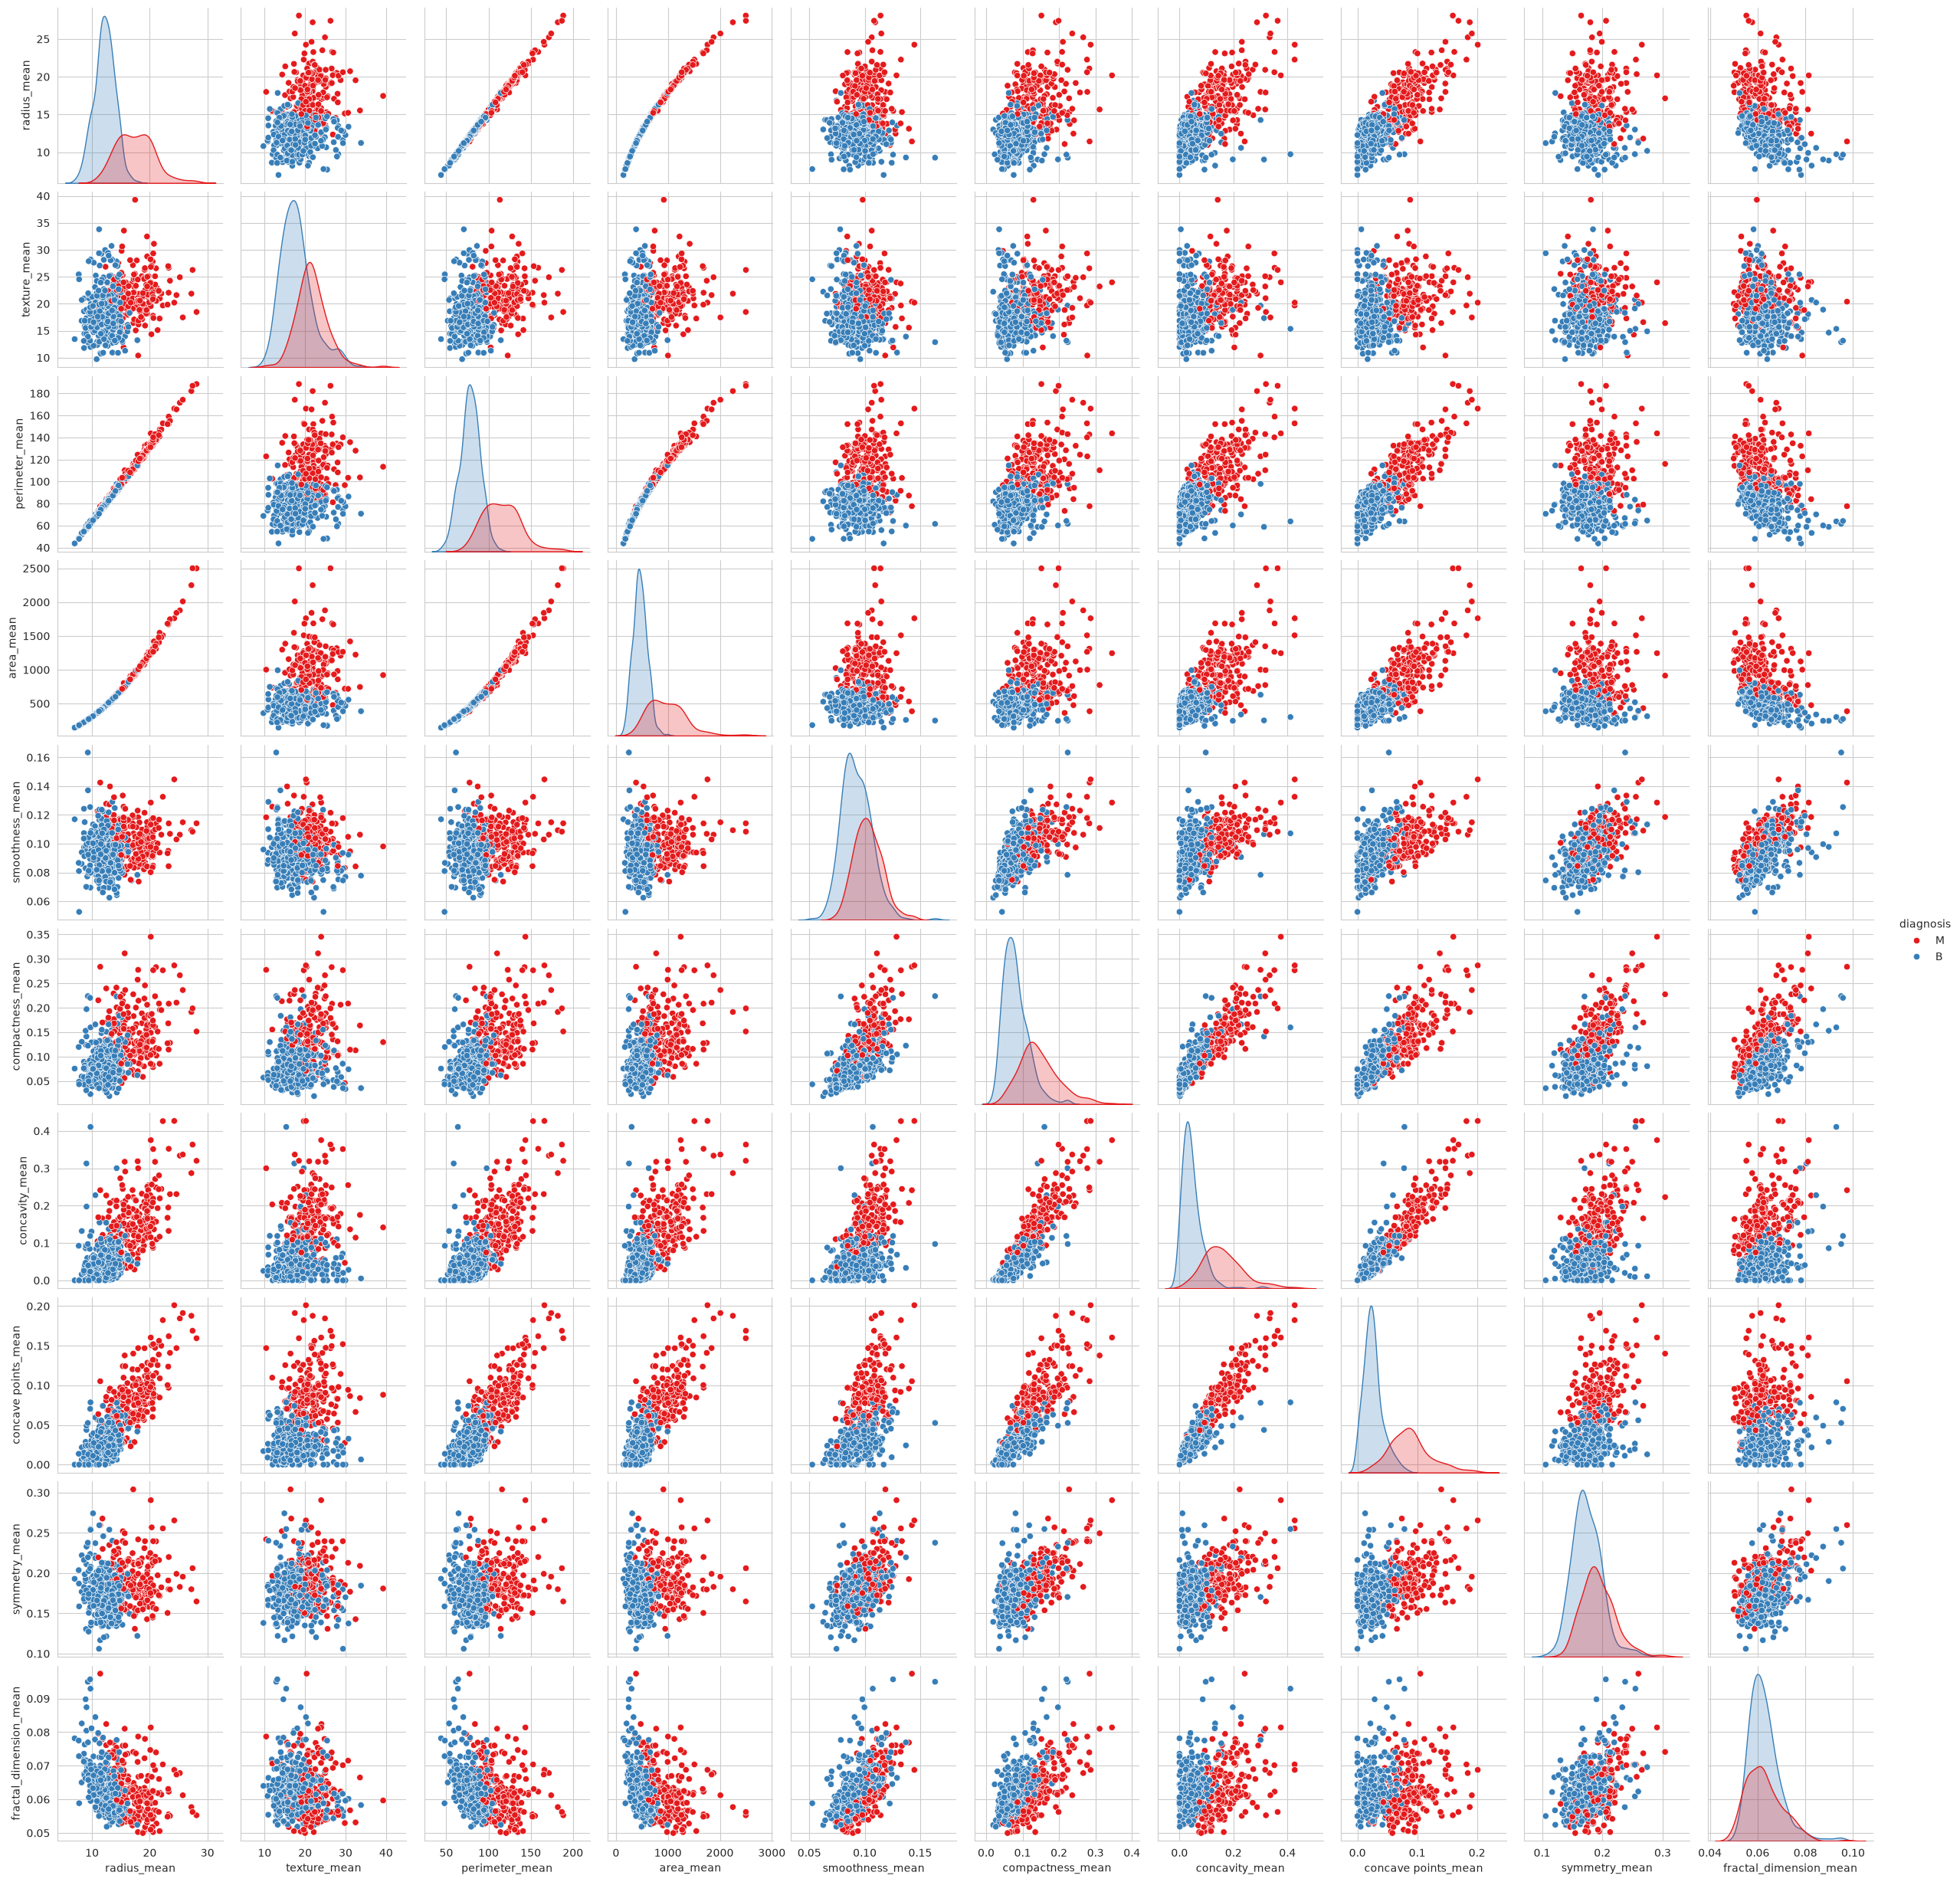

In [325]:
df_treino2_mean_cols = [col for col in df_treino2.columns if ('_mean' in col or col == 'diagnosis')]
df_treino2[df_treino2_mean_cols]
sns.pairplot(df_treino2[df_treino2_mean_cols], hue='diagnosis')

Podemos ver que existe uma divisão clara entre os diagnósticos malignos e benignos, sendo, de maneira geral, os valores dos malignos maiores que dos benignos.

### 2.2 Pré-processamento

Podemos ver que todos os dados são numéricos contínuos, então não temos colunas categóricas para quebrar. Além disso, não temos valores nulos e todos os tipos parecem adequados. Não temos tratamento pra fazer aqui.

No entanto, é importante normalizar os valores para que a classificação não fique enviezada em relação a magnetude de cada dado. Para isso, podemos usar o scaler do próprio scikitlearn mais uma vez.

Vamos aproveitar e também já dividir em treino e verificação.

In [326]:
df_treino_set2 = df_treino2.sample(frac=0.8, random_state=3721)
df_verificacao_set2 = df_treino2.drop(df_treino_set2.index)
df_treino_set2.shape, df_verificacao_set2.shape

((455, 31), (114, 31))

In [350]:
scaler = sk.preprocessing.StandardScaler()
df_treino_set2_normalizado = scaler.fit_transform(df_treino_set2.drop('diagnosis', axis=1))
df_verificacao_set2_normalizado = scaler.fit_transform(df_verificacao_set2.drop('diagnosis', axis=1))
df_treino_set2_normalizado

array([[-0.86793151, -0.98247419, -0.83703904, ..., -0.08471366,
         0.68407421,  0.42457674],
       [ 0.19829448, -0.59099699,  0.26224511, ...,  1.37261714,
         1.15172633,  1.31591712],
       [ 0.19549598, -0.5291848 ,  0.11041028, ..., -0.51012567,
        -0.59373578, -0.8545251 ],
       ...,
       [-0.80076767, -0.24301725, -0.73824518, ...,  0.13419212,
         0.69560085,  2.63305706],
       [ 1.76545078,  0.32473916,  1.72228881, ...,  0.73886194,
         0.55069456, -1.10489524],
       [-0.45375449, -0.27048934, -0.51595899, ..., -1.48004667,
        -1.07456119, -1.59598405]], shape=(455, 30))

### 2.3 Modelo de inferência

Vamos tentar usar o KNN!

In [366]:
knn = sk.neighbors.KNeighborsClassifier(n_neighbors=3)
knn.fit(df_treino_set2_normalizado, df_treino_set2['diagnosis'])

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](2,)","['B','M']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [367]:
knn_prediction = knn.predict(df_verificacao_set2_normalizado)
knn_prediction

array(['M', 'M', 'M', 'M', 'B', 'B', 'M', 'M', 'M', 'M', 'M', 'M', 'B',
       'M', 'M', 'B', 'M', 'B', 'B', 'B', 'B', 'M', 'B', 'M', 'B', 'B',
       'M', 'B', 'M', 'M', 'B', 'B', 'B', 'B', 'M', 'B', 'M', 'B', 'B',
       'B', 'M', 'B', 'M', 'B', 'B', 'M', 'B', 'M', 'B', 'B', 'M', 'B',
       'B', 'M', 'B', 'M', 'M', 'M', 'B', 'B', 'B', 'B', 'B', 'M', 'B',
       'B', 'B', 'M', 'M', 'M', 'B', 'M', 'B', 'B', 'B', 'M', 'M', 'M',
       'B', 'B', 'M', 'B', 'B', 'M', 'B', 'B', 'M', 'B', 'B', 'B', 'B',
       'B', 'B', 'B', 'B', 'B', 'M', 'B', 'B', 'B', 'M', 'B', 'B', 'B',
       'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B'], dtype=object)

In [353]:
pct_malignos = np.count_nonzero(knn_prediction == 'M')/knn_prediction.size
acuracia     = np.count_nonzero(knn_prediction == df_verificacao_set2['diagnosis'])/knn_prediction.size

print(f"Porcentagem de malignos encontrados:\t{(pct_malignos*100):.2f}%")
print(f"Acurácia:\t\t\t\t{(acuracia*100):.2f}%")

Porcentagem de malignos encontrados:	37.72%
Acurácia:				96.49%


Mesmo tendo chutado um valor fixo k=3, temos uma acurácia de 96,49%! Porém, talvez possamos fazer melhor. Vamos experimentar vários valores de k para encontrar o mais apropriado!

1:	95.6140350877193%
2:	94.73684210526315%
3:	96.49122807017544%
4:	96.49122807017544%
5:	96.49122807017544%
6:	95.6140350877193%
7:	96.49122807017544%
8:	94.73684210526315%
9:	95.6140350877193%
10:	95.6140350877193%
11:	96.49122807017544%
12:	95.6140350877193%
13:	96.49122807017544%
14:	94.73684210526315%
15:	96.49122807017544%
16:	96.49122807017544%
17:	96.49122807017544%
18:	96.49122807017544%
19:	96.49122807017544%
20:	95.6140350877193%
21:	95.6140350877193%
22:	95.6140350877193%
23:	95.6140350877193%
24:	95.6140350877193%
25:	95.6140350877193%
26:	95.6140350877193%
27:	95.6140350877193%
28:	95.6140350877193%
29:	95.6140350877193%
30:	95.6140350877193%
31:	95.6140350877193%


<Axes: >

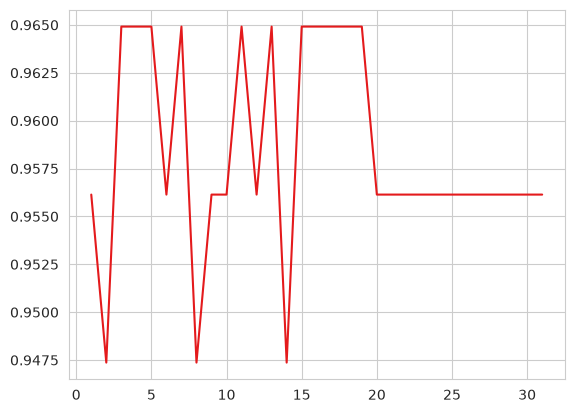

In [354]:
ks = range(1, 32)
acuracias = []

for k in ks:
    print(k, end=':\t')
    knn = sk.neighbors.KNeighborsClassifier(n_neighbors=k)
    knn.fit(df_treino_set2_normalizado, df_treino_set2['diagnosis'])

    knn_prediction = knn.predict(df_verificacao_set2_normalizado)

    acuracia = np.count_nonzero(knn_prediction == df_verificacao_set2['diagnosis'])/knn_prediction.size
    acuracias.append(acuracia)
    print(f"{acuracia*100}%")

sns.lineplot(x=ks, y=acuracias)

Parece que k $\in$ [3,4,5,7,11,13,15,16,17,18,19] são bons valores.

Vamos escolher arbitrariamente k=4.

In [355]:
knn = sk.neighbors.KNeighborsClassifier(n_neighbors=4)
knn.fit(df_treino_set2_normalizado, df_treino_set2['diagnosis'])

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",4
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](2,)","['B','M']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [356]:
df_teste_set2_normalizado = scaler.transform(df_teste2)
knn_prediction = knn.predict(df_teste_set2_normalizado)
knn_prediction

array(['B', 'M', 'M', 'M', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'M',
       'B', 'B', 'B', 'B', 'M', 'B', 'B'], dtype=object)

### 2.4 Avaliação

In [357]:
knn_prediction = knn.predict(df_verificacao_set2_normalizado)

In [358]:
pct_malignos = np.count_nonzero(knn_prediction == 'M')/knn_prediction.size
acuracia = np.count_nonzero(knn_prediction == df_verificacao_set2['diagnosis'])/knn_prediction.size

print(f"Porcentagem de malignos encontrados:\t{(pct_malignos*100):.2f}%")
print(f"Acurácia:\t\t\t\t{(acuracia*100):.2f}%")

Porcentagem de malignos encontrados:	35.96%
Acurácia:				96.49%


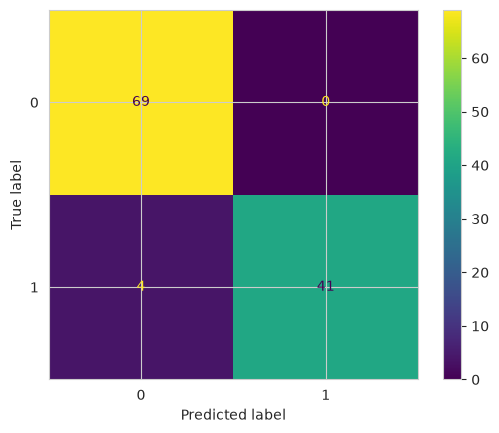

In [359]:
confusao = sk.metrics.confusion_matrix(df_verificacao_set2['diagnosis'], knn_prediction)
sk.metrics.ConfusionMatrixDisplay(confusao).plot()

Como visto anteriormente, nossa acurácia é de 96,49% e a porcentagem de malignos encontrados é 35,96%. Tivemos 4 casos não detectados e 0 falsos positivos.

Esses valores são razoáveis, porém, considerando que estamos lidando com uma condição médica letal, talvez seja melhor ter mais falsos positivos do que casos positivos não diagnosticados.

De maneira geral, há muita coisa para melhorar nesse modelo, com ajustes finos de parâmetros, modelos mais adequados para o problema e uma maior quantidade de dados.